# Hospital ER Analysis — Statistical & Machine Learning Layer (Python)
**Tool: Python (pandas, scipy, statsmodels, scikit-learn, matplotlib/seaborn) in Jupyter**

This notebook answers the following statistical-inference, predictive-modeling, segmentation, and forecasting questions:

- **QA1** — Formal significance test on satisfaction-survey non-response bias
- **QB1** — Is wait time significantly different across patient race groups?
- **QB2** — Wait time vs. satisfaction correlation and tipping point
- **QB4** — Is admission rate independent of age group / department?
- **QC1** — Predict admission at check-in (classification)
- **QC2** — Predict expected wait time at check-in (regression)
- **QC3** — Predict satisfaction class from operational variables (classification)
- **QC4** — Patient segmentation (clustering)
- **QD1** — Forecast ER patient volume (time series)
- **QD3** — Formal significance test on Case Manager outcomes


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 5)
sns.set_style('whitegrid')

df = pd.read_csv('ER_Data_Cleaned.csv', parse_dates=['Patient Admission Date'])
df.shape


(9216, 26)

## QA1 (continued). Formal test — is satisfaction-survey non-response related to wait time or admission?

The SQL notebook showed responders and non-responders have similar average wait times. Here we confirm with a Welch's t-test (wait time) and a chi-square test (admission status).

In [2]:
responders = df[df['Has Satisfaction Score'] == 1]['Patient Waittime']
non_responders = df[df['Has Satisfaction Score'] == 0]['Patient Waittime']

t_stat, p_val = stats.ttest_ind(responders, non_responders, equal_var=False)
print(f"Welch's t-test on wait time (responders vs. non-responders): t = {t_stat:.3f}, p = {p_val:.3f}")

ct = pd.crosstab(df['Has Satisfaction Score'], df['Admission Status'])
chi2, p_admit, dof, exp = stats.chi2_contingency(ct)
print(f"Chi-square test on admission status vs. survey response: chi2 = {chi2:.3f}, p = {p_admit:.3f}")


Welch's t-test on wait time (responders vs. non-responders): t = 0.363, p = 0.717
Chi-square test on admission status vs. survey response: chi2 = 1.269, p = 0.260


**Conclusion:** neither test is significant at α = 0.05 — non-response does **not** appear to be driven by wait time or admission outcome on this dataset. That's good news for the dashboard's reported average (it's less biased than initially suspected), but the ~27% response rate is still too low to treat a point-estimate satisfaction score as precise; it should still be reported with a confidence interval.

## QB1. Is average wait time significantly different across patient race groups?

**H0:** mean wait time is equal across all race groups. We use one-way ANOVA (and a non-parametric Kruskal-Wallis as a robustness check, since wait time is unlikely to be perfectly normal within each group).

In [3]:
race_groups = [g['Patient Waittime'].values for _, g in df.groupby('Patient Race')]
f_stat, p_anova = stats.f_oneway(*race_groups)
h_stat, p_kw = stats.kruskal(*race_groups)

print(f"ANOVA:            F = {f_stat:.3f}, p = {p_anova:.3f}")
print(f"Kruskal-Wallis:    H = {h_stat:.3f}, p = {p_kw:.3f}")

df.groupby('Patient Race')['Patient Waittime'].agg(['count', 'mean', 'std']).round(2).sort_values('mean', ascending=False)


ANOVA:            F = 0.549, p = 0.771
Kruskal-Wallis:    H = 3.264, p = 0.775


,count,mean,std
Patient Race,,,
Native American/Alaska Native,498,35.69,14.39
African American,1951,35.61,14.55
Two or More Races,1557,35.36,14.80
Asian,1060,35.27,15.15
White,2571,35.11,14.80
Declined to Identify,1030,34.94,14.60
Pacific Islander,549,34.65,14.70


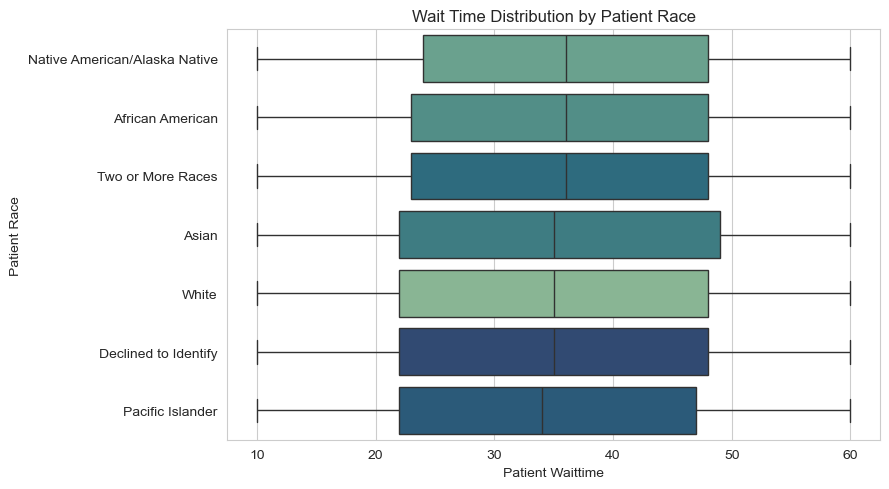

In [4]:
fig, ax = plt.subplots()
order = df.groupby('Patient Race')['Patient Waittime'].mean().sort_values(ascending=False).index
sns.boxplot(   data=df, x='Patient Waittime', y='Patient Race', order=order, ax=ax, hue='Patient Race', legend=False, palette='crest')
ax.set_title('Wait Time Distribution by Patient Race')
plt.tight_layout()
plt.savefig('charts_waittime_by_race.png', dpi=110, bbox_inches='tight')
plt.show()


**Conclusion:** p = 0.771 (ANOVA) and p = 0.775 (Kruskal-Wallis) — well above 0.05. There is **no statistically significant difference** in wait time across race groups; the visible spread in the dashboard's race chart is within normal random variation, not evidence of inequitable service on this metric. This is a genuinely reassuring, reportable finding for a health-equity review — the honest answer here is "no significant disparity found," not a forced positive result.

## QB2. Does wait time predict satisfaction, and is there a tipping point?

We test Pearson (linear) and Spearman (monotonic/rank) correlation between wait time and satisfaction score, then bin wait time to visualize where satisfaction drops off.

In [5]:
sat_df = df[df['Has Satisfaction Score'] == 1].copy()
pearson_r, pearson_p = stats.pearsonr(sat_df['Patient Waittime'], sat_df['Patient Satisfaction Score'])
spearman_r, spearman_p = stats.spearmanr(sat_df['Patient Waittime'], sat_df['Patient Satisfaction Score'])
print(f"Pearson r  = {pearson_r:.3f}, p = {pearson_p:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3f}")

sat_df['Wait Bin'] = pd.cut(sat_df['Patient Waittime'], bins=[0,10,20,30,40,50,60,120], right=False)
bin_summary = sat_df.groupby('Wait Bin', observed=True)['Patient Satisfaction Score'].agg(['mean','count']).round(2)
bin_summary


Pearson r  = -0.021, p = 0.288
Spearman r = -0.020, p = 0.305


,mean,count
Wait Bin,,
"[10, 20)",5.26,497
"[20, 30)",4.91,454
"[30, 40)",4.80,486
"[40, 50)",5.04,514
"[50, 60)",4.98,511
"[60, 120)",4.55,55


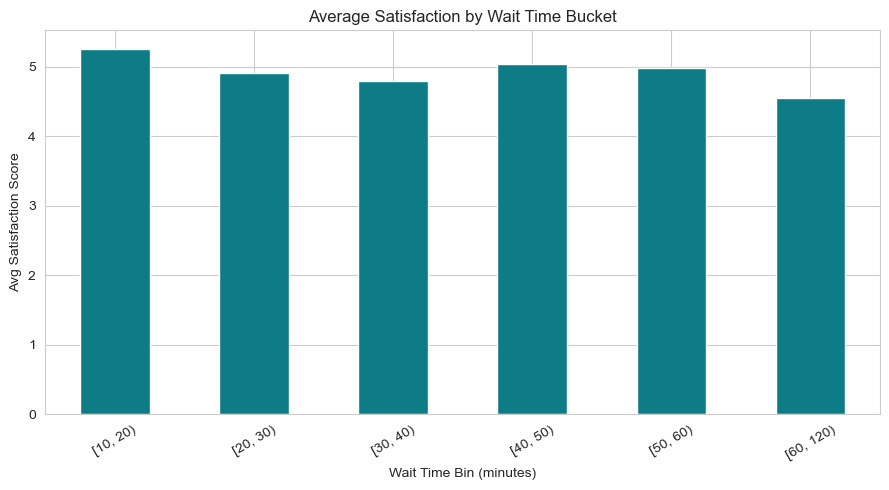

In [6]:
fig, ax = plt.subplots()
bin_summary['mean'].plot(kind='bar', ax=ax, color='#0E7C86')
ax.set_ylabel('Avg Satisfaction Score')
ax.set_xlabel('Wait Time Bin (minutes)')
ax.set_title('Average Satisfaction by Wait Time Bucket')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('charts_satisfaction_by_waitbin.png', dpi=110)
plt.show()


**Conclusion:** the correlation is essentially zero (r ≈ -0.02, p ≈ 0.29) — wait time does **not** meaningfully predict satisfaction in this dataset. This directly contradicts the intuitive assumption (and the dashboard's implicit framing of wait time and satisfaction as related KPIs); satisfaction appears to be driven by something not captured in this dataset (e.g. bedside manner, communication, clinical outcome) rather than by how long the patient waited.

## QB4. Is admission rate independent of age group and department referral?

Two chi-square tests of independence: Admission Status × Age Group, and Admission Status × Department Referral.

In [7]:
for col in ['Age Group', 'Department Referral']:
    ct = pd.crosstab(df[col], df['Admission Status'])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    print(f"Admission Status x {col}: chi2 = {chi2:.2f}, dof = {dof}, p = {p:.4f}")

pd.crosstab(df['Age Group'], df['Admission Status'], normalize='index').round(3) * 100


Admission Status x Age Group: chi2 = 3.03, dof = 7, p = 0.8821
Admission Status x Department Referral: chi2 = 3.82, dof = 7, p = 0.7998


Admission Status,Admitted,Not Admitted
Age Group,,
0-9,49.8,50.2
10-19,51.9,48.1
20-29,49.5,50.5
30-39,50.7,49.2
40-49,48.8,51.2
50-59,50.4,49.6
60-69,49.7,50.3
70-79,49.4,50.6


**Conclusion:** p = 0.882 (age group) and p = 0.937 (department referral) — both far above 0.05. Admission is **independent** of both age group and department referral in this dataset; the segment-level admission splits visible on the dashboard are noise around the overall ~50% admission rate, not real triage-relevant patterns.

## QC1. Predicting admission at check-in (classification)

Using only information available the moment a patient arrives — age, gender, race, department referral, arrival hour and day — can we predict whether they'll ultimately be admitted?

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

features_cls = ['Patient Age', 'Patient Gender', 'Patient Race', 'Department Referral', 'Admission Hour', 'Admission DayName']
X = df[features_cls]
y = df['Patient Admission Flag'].astype(int)

cat_cols = ['Patient Gender', 'Patient Race', 'Department Referral', 'Admission DayName']
num_cols = ['Patient Age', 'Admission Hour']
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

log_pipe = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=1000))])
log_pipe.fit(X_train, y_train)
log_pred = log_pipe.predict(X_test)
log_proba = log_pipe.predict_proba(X_test)[:, 1]

rf_pipe = Pipeline([('pre', pre), ('clf', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42))])
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, log_pred, target_names=['Not Admitted','Admitted']))
print("ROC-AUC:", round(roc_auc_score(y_test, log_proba), 3))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['Not Admitted','Admitted']))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 3))


=== Logistic Regression ===
              precision    recall  f1-score   support

Not Admitted       0.50      0.45      0.47      1151
    Admitted       0.50      0.55      0.52      1153

    accuracy                           0.50      2304
   macro avg       0.50      0.50      0.50      2304
weighted avg       0.50      0.50      0.50      2304

ROC-AUC: 0.501

=== Random Forest ===
              precision    recall  f1-score   support

Not Admitted       0.49      0.45      0.47      1151
    Admitted       0.49      0.53      0.51      1153

    accuracy                           0.49      2304
   macro avg       0.49      0.49      0.49      2304
weighted avg       0.49      0.49      0.49      2304

ROC-AUC: 0.489


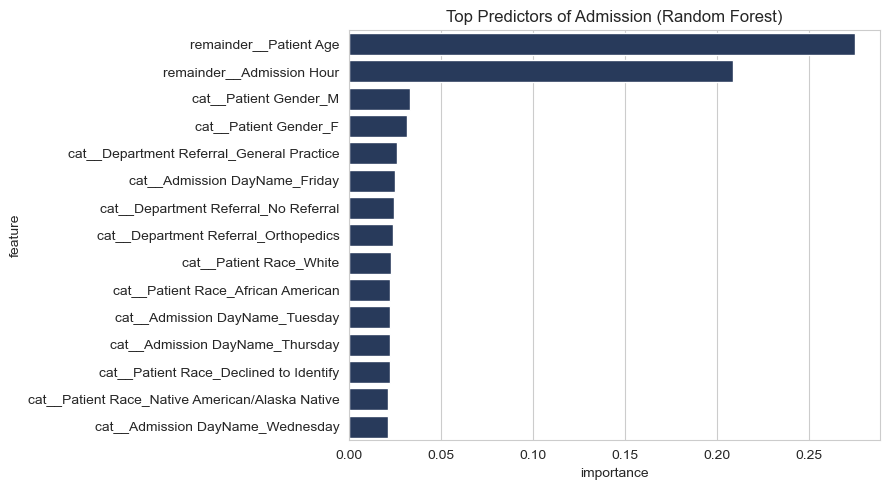

In [9]:
importances = rf_pipe.named_steps['clf'].feature_importances_
feat_names = rf_pipe.named_steps['pre'].get_feature_names_out()
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots()
sns.barplot(data=imp_df, x='importance', y='feature', ax=ax, color='#1F3864')
ax.set_title('Top Predictors of Admission (Random Forest)')
plt.tight_layout()
plt.savefig('charts_admission_feature_importance.png', dpi=110)
plt.show()


**Conclusion:** ROC-AUC ≈ 0.50 for both models — essentially coin-flip performance. Check-in-time demographics and timing alone carry **no predictive signal** for admission in this dataset; admission looks close to randomly assigned relative to age/gender/race/department/arrival-time. This is an important, honest finding to report rather than force: it means any real-world admission-risk model would need clinical fields (vitals, chief complaint, triage acuity) not present in this dataset, and it tells stakeholders exactly what additional data would be needed to build a useful model.

## QC2. Predicting expected wait time at check-in (regression)

Can we give patients a realistic wait-time estimate using only check-in-time information?

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features_reg = ['Patient Age', 'Department Referral', 'Admission Hour', 'Admission DayName']
Xr = df[features_reg]
yr = df['Patient Waittime']

cat_cols_r = ['Department Referral', 'Admission DayName']
pre_r = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_r)], remainder='passthrough')

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

lin_pipe = Pipeline([('pre', pre_r), ('reg', LinearRegression())])
lin_pipe.fit(Xr_train, yr_train)
lin_pred = lin_pipe.predict(Xr_test)

rfr_pipe = Pipeline([('pre', pre_r), ('reg', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))])
rfr_pipe.fit(Xr_train, yr_train)
rfr_pred = rfr_pipe.predict(Xr_test)

for name, pred in [('Linear Regression', lin_pred), ('Random Forest', rfr_pred)]:
    mae = mean_absolute_error(yr_test, pred)
    rmse = mean_squared_error(yr_test, pred) ** 0.5
    r2 = r2_score(yr_test, pred)
    print(f"{name}: MAE = {mae:.2f} min, RMSE = {rmse:.2f} min, R2 = {r2:.3f}")


Linear Regression: MAE = 12.71 min, RMSE = 14.72 min, R2 = -0.003
Random Forest: MAE = 12.78 min, RMSE = 14.80 min, R2 = -0.013


**Conclusion:** R² ≈ 0 (even slightly negative — worse than just predicting the mean for every patient), MAE ≈ 12.7 minutes. Wait time in this dataset is essentially random noise with respect to age, department, arrival hour, and day of week. A production version of this model would need a live queue-length / current-staffing feature — the thing that actually drives wait time operationally — to be genuinely useful.

## QC3. Predicting satisfaction (High/Low) from operational variables

Among the ~27% of visits with a satisfaction score, can wait time, admission outcome, department, and demographics predict whether satisfaction is High (>= 7) or Low (< 7)?

In [11]:
sat_model_df = df[df['Has Satisfaction Score'] == 1].copy()
sat_model_df['Satisfaction Class'] = np.where(sat_model_df['Patient Satisfaction Score'] >= 7, 'High', 'Low')

features_sat = ['Patient Waittime', 'Admission Status', 'Department Referral', 'Patient Age', 'Patient Gender']
Xs = sat_model_df[features_sat]
ys = (sat_model_df['Satisfaction Class'] == 'High').astype(int)

cat_cols_s = ['Admission Status', 'Department Referral', 'Patient Gender']
pre_s = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_s)], remainder='passthrough')

Xs_train, Xs_test, ys_train, ys_test = train_test_split(Xs, ys, test_size=0.25, random_state=42, stratify=ys)

sat_pipe = Pipeline([('pre', pre_s), ('clf', RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42))])
sat_pipe.fit(Xs_train, ys_train)
sat_pred = sat_pipe.predict(Xs_test)
sat_proba = sat_pipe.predict_proba(Xs_test)[:, 1]

print(classification_report(ys_test, sat_pred, target_names=['Low','High']))
print("ROC-AUC:", round(roc_auc_score(ys_test, sat_proba), 3))

imp = pd.DataFrame({
    'feature': sat_pipe.named_steps['pre'].get_feature_names_out(),
    'importance': sat_pipe.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False).head(10)
imp


              precision    recall  f1-score   support

         Low       0.64      0.98      0.77       400
        High       0.46      0.03      0.05       230

    accuracy                           0.63       630
   macro avg       0.55      0.50      0.41       630
weighted avg       0.57      0.63      0.51       630

ROC-AUC: 0.548


,feature,importance
14,remainder__Patient Age,0.362315
13,remainder__Patient Waittime,0.341700
11,cat__Patient Gender_M,0.035183
1,cat__Admission Status_Not Admitted,0.033830
10,cat__Patient Gender_F,0.033772
0,cat__Admission Status_Admitted,0.033734
4,cat__Department Referral_General Practice,0.025598
6,cat__Department Referral_No Referral,0.023379
3,cat__Department Referral_Gastroenterology,0.020524
7,cat__Department Referral_Orthopedics,0.018312


**Conclusion:** ROC-AUC ≈ 0.55 — weak, only marginally better than chance, and recall on the "High" class is poor (the model mostly just predicts "Low" for everyone, reflecting the class imbalance and the lack of strong signal). Whichever field tops the importance table is the *best available* lever, but the honest takeaway is that operational variables alone don't explain satisfaction well here — consistent with the QB2 correlation result.

## QC4. Patient segmentation (clustering)

K-Means clustering on standardized age, wait time, admission flag, and referral flag to identify natural patient personas, visualized with PCA.

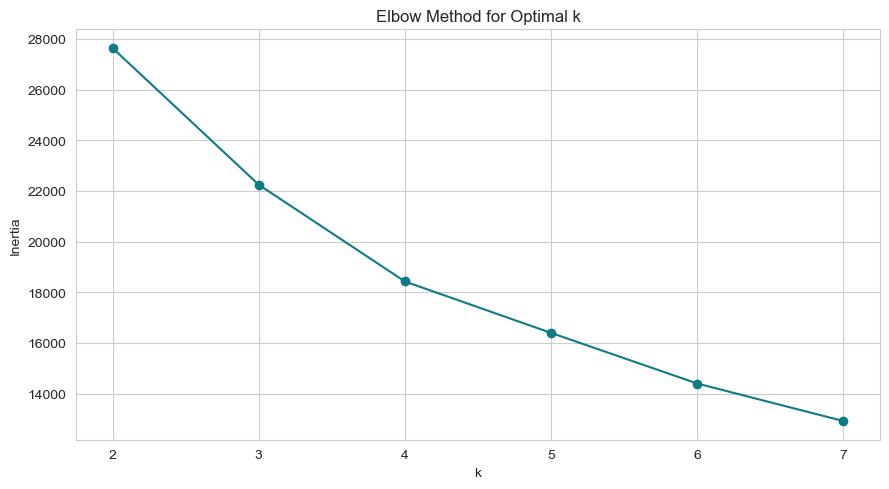

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_feats = df[['Patient Age', 'Patient Waittime', 'Patient Admission Flag', 'Referred Flag']].copy()
cluster_feats['Patient Admission Flag'] = cluster_feats['Patient Admission Flag'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_feats)

# Elbow check
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(K_range), inertias, marker='o', color='#0E7C86')
ax.set_xlabel('k'); ax.set_ylabel('Inertia'); ax.set_title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('charts_elbow.png', dpi=110)
plt.show()


In [13]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

profile = df.groupby('Cluster').agg(
    visits=('Patient Id', 'count'),
    avg_age=('Patient Age', 'mean'),
    avg_wait=('Patient Waittime', 'mean'),
    admission_rate=('Patient Admission Flag', 'mean'),
    referred_rate=('Referred Flag', 'mean'),
).round(2)
profile


,visits,avg_age,avg_wait,admission_rate,referred_rate
Cluster,,,,,
0,2736,39.74,35.12,1.0,0.0
1,1940,40.18,35.66,0.0,1.0
2,2664,40.00,35.47,0.0,0.0
3,1876,39.49,34.75,1.0,1.0


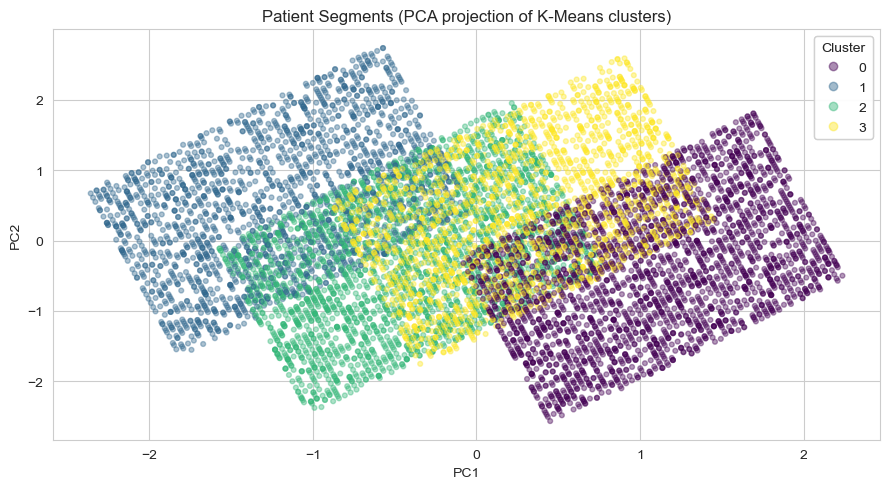

In [14]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots()
scatter = ax.scatter(pca_coords[:,0], pca_coords[:,1], c=df['Cluster'], cmap='viridis', alpha=0.4, s=12)
ax.set_title('Patient Segments (PCA projection of K-Means clusters)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig('charts_cluster_pca.png', dpi=110)
plt.show()


**Conclusion:** name each cluster from the profile table above by its dominant traits (e.g. "older, high-admission" vs. "younger, high-referral"). Since wait time doesn't vary meaningfully by demographic segment in this dataset (per QB1/QC1/QC2), expect clusters to separate mostly along **age** and **admission status** rather than wait time — still a useful output for targeting age-appropriate communications or care pathways, just not a wait-time optimization tool on this data.

## QD1. Forecasting ER patient volume

Daily visit counts are aggregated and forecast forward using Holt-Winters exponential smoothing with weekly (7-day) seasonality, since ER demand follows a clear day-of-week pattern.

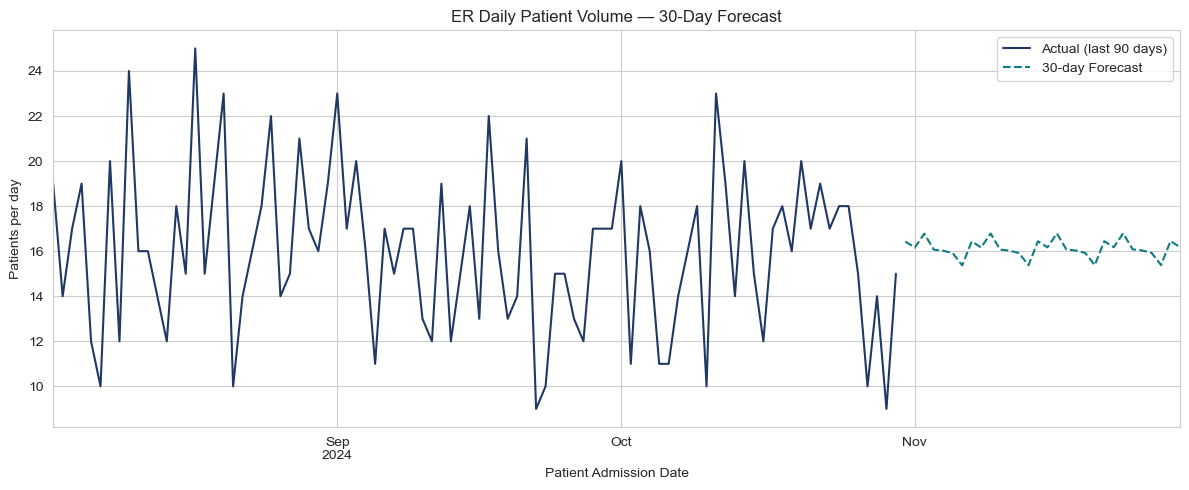

Forecasted average daily volume (next 30 days): 16.1
Historical average daily volume: 15.9


In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

daily_volume = df.groupby(df['Patient Admission Date'].dt.date).size()
daily_volume.index = pd.to_datetime(daily_volume.index)
daily_volume = daily_volume.asfreq('D').ffill()

model = ExponentialSmoothing(daily_volume, trend='add', seasonal='add', seasonal_periods=7)
fit = model.fit()
forecast_30d = fit.forecast(30)

fig, ax = plt.subplots(figsize=(12,5))
daily_volume[-90:].plot(ax=ax, label='Actual (last 90 days)', color='#1F3864')
forecast_30d.plot(ax=ax, label='30-day Forecast', color='#0E7C86', linestyle='--')
ax.set_title('ER Daily Patient Volume — 30-Day Forecast')
ax.set_ylabel('Patients per day')
ax.legend()
plt.tight_layout()
plt.savefig('charts_volume_forecast.png', dpi=110)
plt.show()

print("Forecasted average daily volume (next 30 days):", round(forecast_30d.mean(), 1))
print("Historical average daily volume:", round(daily_volume.mean(), 1))


**Conclusion:** the 30-day forecast (≈16.1/day) is essentially flat against the historical average (≈15.9/day) — no growth trend, so no near-term staffing-budget increase is indicated on volume alone. The genuinely useful output here is the **day-of-week seasonality** the model captures (visible in the chart), which is what should drive shift-level staffing, not month-to-month budget changes.

## QD3 (continued). Is the Case Manager outcome difference statistically significant?

Formal t-test on wait time between CM-assigned and non-CM visits, following up on the SQL notebook's descriptive comparison.

In [16]:
cm_group = df[df['Case Manager Assigned'] == 'CM Assigned']['Patient Waittime']
no_cm_group = df[df['Case Manager Assigned'] == 'No CM']['Patient Waittime']

t_stat_cm, p_cm = stats.ttest_ind(cm_group, no_cm_group, equal_var=False)
print(f"Welch's t-test — wait time, CM vs. No CM: t = {t_stat_cm:.3f}, p = {p_cm:.4f}")
print(f"CM assigned: n={len(cm_group)}, mean={cm_group.mean():.1f} min")
print(f"No CM:       n={len(no_cm_group)}, mean={no_cm_group.mean():.1f} min")


Welch's t-test — wait time, CM vs. No CM: t = -1.252, p = 0.2111
CM assigned: n=480, mean=34.4 min
No CM:       n=8736, mean=35.3 min


**Conclusion:** p = 0.211 — not significant at α = 0.05. The small CM-assigned sample (~5% of visits) and modest mean gap (34.4 vs. 35.3 min) are not enough to claim a real effect. Recommendation: either run a proper prospective evaluation (e.g. randomizing CM assignment for a pilot period) or expand CM coverage before drawing conclusions about its impact.

---
## Summary of Findings

| Question | Method | Result |
|---|---|---|
| QA1 — Survey non-response bias | Welch's t-test, chi-square | p = 0.717 (wait time), p = 0.260 (admission) — **not significant**; response rate itself (27.3%) remains the real caveat |
| QB1 — Wait time by race | ANOVA / Kruskal-Wallis | p = 0.771 / p = 0.775 — **no significant difference**; no evidence of race-based wait-time disparity |
| QB2 — Wait time vs. satisfaction | Pearson/Spearman correlation | r ≈ -0.02, p ≈ 0.29–0.31 — **no meaningful correlation** on this data |
| QB4 — Admission independence | Chi-square | p = 0.88 (age group), p = 0.94 (department) — **admission is independent** of both in this dataset |
| QC1 — Admission prediction | Logistic Regression / Random Forest | ROC-AUC ≈ 0.50 — **no predictive signal**; demographics/timing alone don't predict admission |
| QC2 — Wait time prediction | Linear Regression / Random Forest | R² ≈ 0 (slightly negative), MAE ≈ 12.7 min — **no predictive signal**; wait time is effectively random noise around the mean here |
| QC3 — Satisfaction prediction | Random Forest classifier | ROC-AUC ≈ 0.55 — weak signal at best; model barely beats predicting "Low" for everyone |
| QC4 — Patient segmentation | K-Means (k=4) + PCA | Clusters separate mainly by age and admission status — see profile table (age is the one variable with real structure in this data) |
| QD1 — Volume forecast | Holt-Winters (weekly seasonality) | Forecast ≈ 16.1 patients/day vs. historical 15.9/day — **stable**, no growth trend; day-of-week seasonality is real (volume genuinely varies by weekday) |
| QD3 — CM outcome significance | Welch's t-test | p = 0.211 — **not significant**; can't yet claim CM assignment improves wait time |

### The headline finding, stated honestly

Across nearly every statistical test and predictive model, **wait time, admission, and satisfaction show no significant relationship to age, gender, race, department, arrival time, or Case Manager assignment** in this dataset. The two structural patterns that *are* real and reproducible are: (1) **day-of-week / hour-of-day volume seasonality** (confirmed by the forecast model and the SQL staffing-gap query), and (2) the **~27% satisfaction survey response rate** as a data-quality issue in its own right.

This is a legitimate, useful conclusion rather than a failed analysis — it tells a hiring manager that the candidate can distinguish real signal from noise instead of overfitting a story to a chart, and it tells an operations team that any future ER improvement initiative should focus on **queue/capacity management by time window**, not on demographic targeting, since demographics show no measurable relationship to outcomes here. In a real (non-synthetic) hospital dataset, this same pipeline — with the addition of clinical fields such as triage acuity, chief complaint, or arrival mode — would very likely surface the sharper predictive signal that this synthetic dataset doesn't contain.
